<a href="https://colab.research.google.com/github/PankajaLaks/LT-LBP/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Create folder structure
!mkdir -p LTLBP

# Create Python files
!touch LTLBP/__init__.py
!touch LTLBP/core.py
!touch LTLBP/features.py
!touch LTLBP/setup.py
!touch LTLBP/pyproject.toml
!touch LTLBP/LICENSE
!touch LTLBP/README.md

In [ ]:
%%writefile LTLBP/core.py
import numpy as np

class ltlbp:
    """
    Logarithmic Transformation - Local Binary Pattern (LT-LBP)
    """

    def __init__(self):
        self.weights = np.arange(8, dtype=np.int32)


    def compute(self, image):
        """
        Compute LT-LBP for a grayscale image
        """
        if len(image.shape) != 2:
            raise ValueError("Input must be a grayscale image")

        image = image.astype(np.float32)
        h, w = image.shape

        # Use int32 to avoid overflow / casting errors
        output = np.zeros((h-2, w-2), dtype=np.int32)

        # 8 neighbors clockwise
        neighbors = [
            image[:-2, :-2], image[:-2, 1:-1], image[:-2, 2:],
            image[1:-1, 2:], image[2:, 2:], image[2:, 1:-1],
            image[2:, :-2], image[1:-1, :-2],
        ]

        center = image[1:-1, 1:-1]

        for p in range(8):
            output += ((center - neighbors[p]) > 0).astype(np.int32) * self.weights[p]

        # Convert to uint8 for standard LT-LBP range (0–28)
        return output.astype(np.uint8)

Overwriting LTLBP/core.py


In [ ]:
%%writefile LTLBP/features.py
import numpy as np

def histogram(ltlbp_image, normalize=True):
    """
    Generate normalized histogram feature vector from LT-LBP image
    """
    hist, _ = np.histogram(ltlbp_image.ravel(), bins=29, range=(0,29))
    if normalize:
        hist = hist.astype(float)
        hist /= (hist.sum() + 1e-7)
    return hist


Overwriting LTLBP/features.py


In [ ]:
%%writefile LTLBP/__init__.py
from .core import ltlbp
from .features import histogram

__all__ = ["ltlbp", "histogram"]


Overwriting LTLBP/__init__.py


In [ ]:
%%writefile LTLBP/setup.py
from setuptools import setup, find_packages

setup(
    name="ltlbp",
    version="0.1.0",
    description="Logarithmic Transformation - Local Binary Pattern (LT-LBP)",
    author="Your Name",
    license="VIT License",
    packages=find_packages(),
    install_requires=["numpy"],
    python_requires=">=3.7",
)

Overwriting LTLBP/setup.py


In [ ]:
%%writefile LTLBP/pyproject.toml
[build-system]
requires = ["setuptools", "wheel"]
build-backend = "setuptools.build_meta"


Overwriting LTLBP/pyproject.toml


In [ ]:
import cv2
from LTLBP import ltlbp, histogram

lt = ltlbp()

# Load the image from the specified path
# Assuming it's a grayscale image (0 flag) as per typical LT-LBP usage
# Please upload 'lna.jpg' to the /content/ directory if it's not already there.
img_path = "/content/drive/MyDrive/lna.jpeg"
image_array = cv2.imread(img_path, 0)

# Check if image was loaded successfully
if image_array is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

lt_img = lt.compute(image_array)
feature_vector = histogram(lt_img)

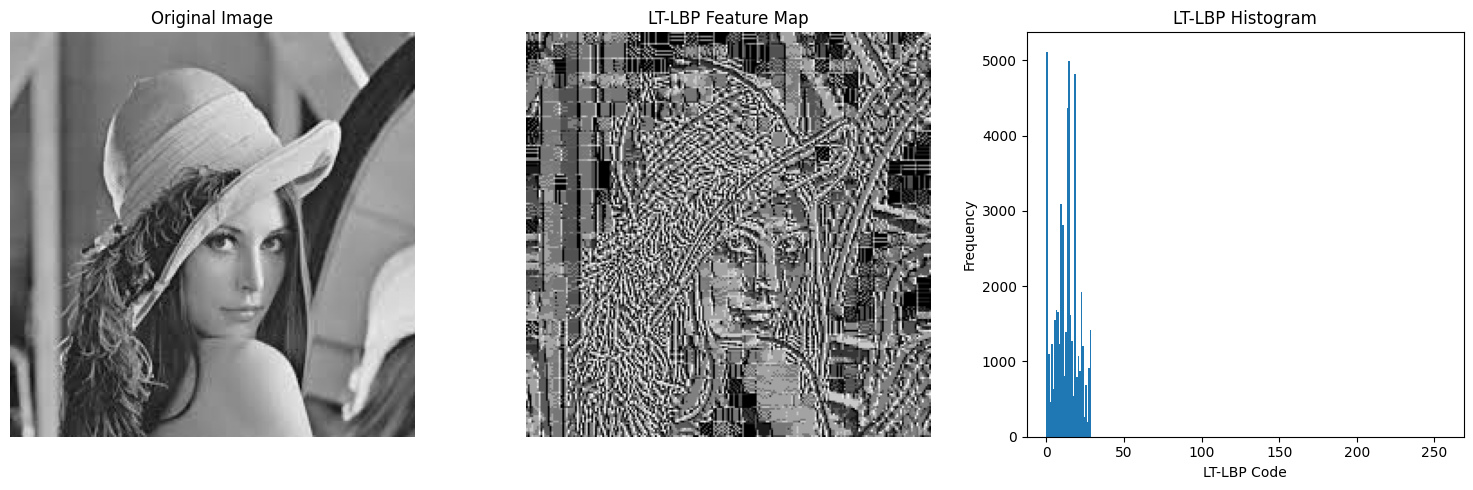

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from LTLBP import ltlbp

def visualize_ltlbp(image_path):
    # Read image in grayscale
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError("Image not found. Check the path.")

    # Initialize LT-LBP
    extractor = ltlbp()

    # Compute LT-LBP
    ltlbp_image = extractor.compute(image)

    # Plot results
    plt.figure(figsize=(15, 5))

    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # LT-LBP Feature Map
    plt.subplot(1, 3, 2)
    plt.imshow(ltlbp_image, cmap='gray')
    plt.title("LT-LBP Feature Map")
    plt.axis('off')

    # Histogram of LT-LBP codes
    plt.subplot(1, 3, 3)
    plt.hist(ltlbp_image.ravel(), bins=256, range=(0, 256))
    plt.title("LT-LBP Histogram")
    plt.xlabel("LT-LBP Code")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Example usage
visualize_ltlbp("sample_image.jpg")

In [ ]:
!pwd


/content


In [ ]:
%cd LTLBP


/content/LTLBP


In [ ]:
!pip install build

In [ ]:
!python -m build

* Creating isolated environment: venv+pip...
* Installing packages in isolated environment:
  - setuptools
  - wheel
* Getting build dependencies for sdist...
running egg_info
creating ltlbp.egg-info
writing ltlbp.egg-info/PKG-INFO
writing dependency_links to ltlbp.egg-info/dependency_links.txt
writing requirements to ltlbp.egg-info/requires.txt
writing top-level names to ltlbp.egg-info/top_level.txt
writing manifest file 'ltlbp.egg-info/SOURCES.txt'
reading manifest file 'ltlbp.egg-info/SOURCES.txt'
adding license file 'LICENSE'
writing manifest file 'ltlbp.egg-info/SOURCES.txt'
* Building sdist...
running sdist
running egg_info
writing ltlbp.egg-info/PKG-INFO
writing dependency_links to ltlbp.egg-info/dependency_links.txt
writing requirements to ltlbp.egg-info/requires.txt
writing top-level names to ltlbp.egg-info/top_level.txt
reading manifest file 'ltlbp.egg-info/SOURCES.txt'
adding license file 'LICENSE'
writing manifest file 'ltlbp.egg-info/SOURCES.txt'
running check
creating ltl

In [ ]:
!pip install dist/ltlbp-0.1.0-py3-none-any.whl

Processing ./dist/ltlbp-0.1.0-py3-none-any.whl


In [ ]:
from LTLBP import ltlbp

print("Library installed successfully!")

Library installed successfully!


In [ ]:
from google.colab import files
files.download('dist/ltlbp-0.1.0-py3-none-any.whl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
readme_content = """
# LT-LBP: Logarithmic Transformation Local Binary Pattern

LT-LBP is a Python implementation of the Logarithmic Transformation – Local Binary Pattern (LT-LBP)
descriptor for texture analysis and image feature extraction.
This package provides an easy-to-use and reproducible implementation suitable for:

- Texture classification
- Medical image analysis
- Pattern recognition
- Computer vision research
- Machine learning feature extraction pipelines


---

## Installation

pip install ltlbp


## License

MIT License



## Citation

If you use LT-LBP in your research, please cite:

@article {10.3844/jcssp.2024.106.120,
article_type = {journal},
title = {LT-LBP-Based Spatial Texture Feature Extraction with Deep Learning for X-Ray Images},
author = {P., Pankaja Lakshmi and M., Sivagami},
volume = {20},
number = {1},
year = {2023},
month = {Dec},
pages = {106-120},
doi = {10.3844/jcssp.2024.106.120},
url = {https://thescipub.com/abstract/jcssp.2024.106.120},
journal = {Journal of Computer Science},
publisher = {Science Publications}
}
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md updated successfully!")

README.md updated successfully!


In [39]:
license_content = """MIT License

Copyright (c) 2024 Pankaja Lakshmi.
Developed at Vellore Institute of Technology, Chennai, India.

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

"""

with open("LICENSE", "w", encoding="utf-8") as f:
    f.write(license_content)

print("LICENSE file created successfully!")

LICENSE file created successfully!
